# MIDI preprocessing

Run the same pipeline as `python -m training.preprocess_dataset` from the `src` directory.

In [10]:
from pathlib import Path
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.utils_checkpoint import torch_load
from src.preprocessing.tokenizer import NoteTokenizer, EOS_ID, PAD_ID, SOS_ID, token_to_note

processed_dir = project_root / 'data' / 'processed'
data = torch_load(processed_dir / 'dataset.pt', map_location="cpu")
tokens = data["tokens"]

print("Tokens shape:", tokens.shape)
print("Sample token sequence:", tokens[0][:20])

Tokens shape: torch.Size([4869, 128])
Sample token sequence: tensor([   1, 1698, 2055, 2182, 2277, 1803, 2438, 2405, 2437, 1844, 2403, 2339,
        2403, 2339, 2277, 2343, 2445, 1798, 1734, 1810])


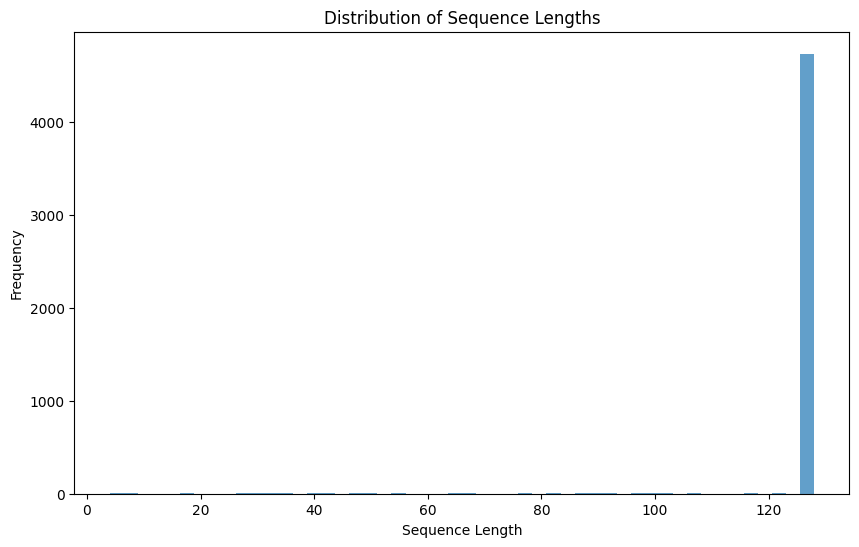

Mean sequence length: 126.16
Median sequence length: 128.00
Max sequence length: 128
Min sequence length: 4


In [11]:
# Analyze sequence lengths
seq_lengths = []
for seq in tokens:
    # Find the EOS or end
    eos_pos = np.where(seq == EOS_ID)[0]
    if len(eos_pos) > 0:
        length = eos_pos[0] + 1  # include EOS
    else:
        length = len(seq)
    seq_lengths.append(length)

plt.figure(figsize=(10, 6))
plt.hist(seq_lengths, bins=50, alpha=0.7)
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.title('Distribution of Sequence Lengths')
plt.show()

print(f"Mean sequence length: {np.mean(seq_lengths):.2f}")
print(f"Median sequence length: {np.median(seq_lengths):.2f}")
print(f"Max sequence length: {np.max(seq_lengths)}")
print(f"Min sequence length: {np.min(seq_lengths)}")

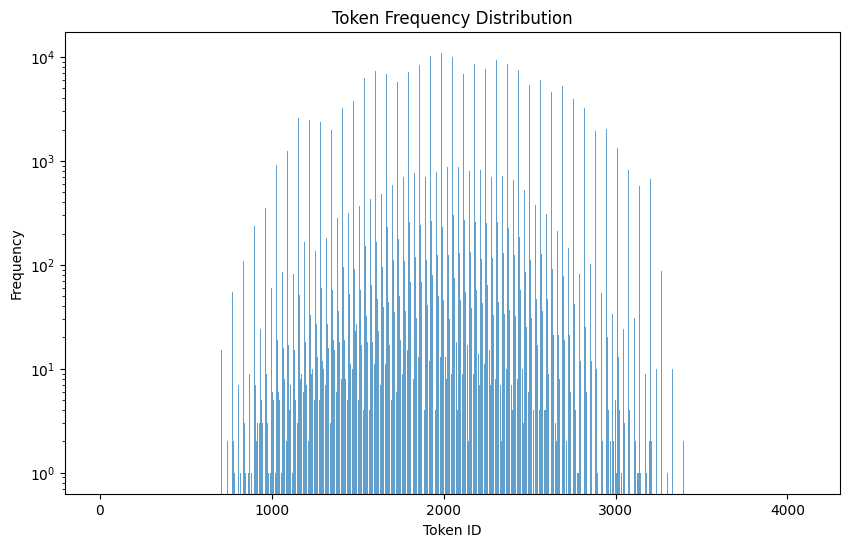

Most common token: 1987 with count 10970
Special tokens: PAD=0, SOS=1, EOS=2


In [12]:
# Token frequency analysis
all_tokens = tokens.flatten()
token_counts = np.bincount(all_tokens, minlength=NoteTokenizer().vocab_size)

plt.figure(figsize=(10, 6))
plt.bar(range(len(token_counts)), token_counts, alpha=0.7)
plt.xlabel('Token ID')
plt.ylabel('Frequency')
plt.title('Token Frequency Distribution')
plt.yscale('log')
plt.show()

print(f"Most common token: {np.argmax(token_counts)} with count {np.max(token_counts)}")
print(f"Special tokens: PAD={PAD_ID}, SOS={SOS_ID}, EOS={EOS_ID}")

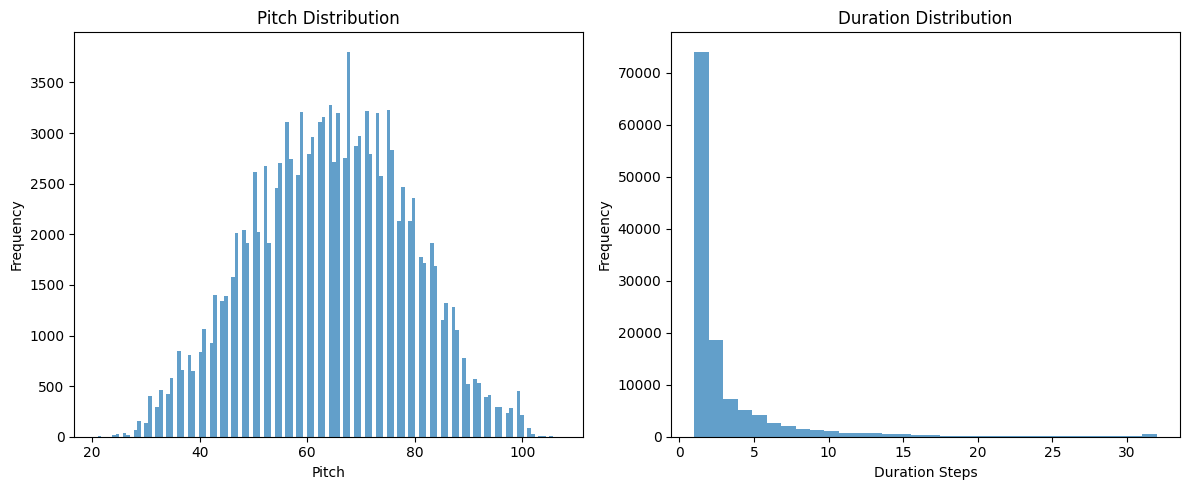

Unique pitches: 87
Unique durations: 32
Mean pitch: 64.42
Mean duration: 2.78


In [13]:
# Analyze pitch and duration distributions
pitches = []
durations = []

for seq in tokens[:1000]:  # sample some sequences
    for t in seq:
        if t > EOS_ID:  # not special
            try:
                p, d = token_to_note(t)
                pitches.append(p)
                durations.append(d)
            except:
                pass

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(pitches, bins=128, alpha=0.7)
plt.xlabel('Pitch')
plt.ylabel('Frequency')
plt.title('Pitch Distribution')

plt.subplot(1, 2, 2)
plt.hist(durations, bins=32, alpha=0.7)
plt.xlabel('Duration Steps')
plt.ylabel('Frequency')
plt.title('Duration Distribution')

plt.tight_layout()
plt.show()

print(f"Unique pitches: {len(set(pitches))}")
print(f"Unique durations: {len(set(durations))}")
print(f"Mean pitch: {np.mean(pitches):.2f}")
print(f"Mean duration: {np.mean(durations):.2f}")